# Robson audit and the two research questions

**Automated Robson Ten-Group Classification and Cesarean Readiness System: ML workstream**

This notebook presents the analytic side of the project: the Robson audit table and the two
research questions.

| § | Section | § | Section |
|---|---|---|---|
| 1 | Robson audit table (with the Vogel 2015 comparison when available) | 4 | RQ2: missingness and under-recording |
| 2 | Facility contributions | 5 | WHO C-Model |
| 3 | RQ1: case-mix adjustment of facility CS rates | 6 | Limitations |

## Purpose

* **Audit.** How many women fall in each Robson group, how often each group has a cesarean, and how
  much each group contributes to the overall CS rate, per facility and overall.
* **RQ1.** How much of the difference in CS rates between the four facilities is explained by the
  recorded case mix (Robson group, maternal age and, where available, the C-Model covariates)?
* **RQ2.** How incomplete are the admission records, and how would conclusions about pre-eclampsia and
  gestational diabetes change if these conditions are under-recorded?

Everything here is **descriptive**. No output is a statement about what care any woman should have
received, and nothing here is a recommendation for or against a cesarean section.

## Data governance

* The notebook **reads the aggregate outputs** that `robson-ml casemix` and `robson-ml missingness`
  write under `reports/casemix/` and `reports/missingness/`. All logic lives in the tested package
  `src/robson_ml` (`audit_offline`, `casemix`, `missingness`, `cmodel`, `references`), so what is shown
  here is exactly what is published and cannot be differenced against it.
* **Aggregates only.** Counts of 1-4 are shown as `<5`; cells hidden to protect another cell as `*`.
  The Robson rows 1-10 are the same jointly suppressed rows as in `reports/profile/robson_inputs.md`.
* **Commit policy:** the notebook is committed with its outputs cleared
  (`uv run python scripts/strip_notebook.py`). An executed copy on real data belongs under `reports/`,
  which is git-ignored.

## Reference values are never invented

Three comparisons need published values, transcribed by hand into `data/reference/`:

| File | Content | Source |
|---|---|---|
| `vogel2015_v1.yaml` | Reference size (%) and CS rate (%) of each Robson group | Vogel et al., 2015, *Lancet Glob Health* 3(5):e260-e270, one table and population |
| `cmodel_v1.yaml` | C-Model intercept, coefficients and variable definitions | Souza et al., 2016, *BJOG* 123(3):427-436 (table / supplement / e-calculator) |
| `prevalence_v1.yaml` | Assumed true-prevalence grid for pre-eclampsia and GDM, with the published anchors | Published regional prevalence studies |

The schemas are printed in section 0 below and documented in `robson_ml.references`. **When a file is
absent, the comparison is reported as not available. Nothing is estimated, approximated or filled in
its place.**

## Modes

* `synthetic` (default): builds a synthetic project in a temporary directory, writes **FAKE** reference
  files (labelled as such, obviously artificial values) so that every code path runs, and executes the
  CLI with small bootstrap and draw counts. No real data is touched, and no number shown in this mode
  means anything.
* `real`: reads `configs/`, `data/processed/` and the `reports/` outputs of `robson-ml casemix` and
  `robson-ml missingness`, which must already have been run.

Set the mode with the environment variable `ROBSON_NOTEBOOK_MODE` (or `scripts/run_notebook.py --mode`).

In [1]:
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path

MODE = os.environ.get("ROBSON_NOTEBOOK_MODE", "synthetic")
if MODE not in {"synthetic", "real"}:
    raise ValueError(f"ROBSON_NOTEBOOK_MODE must be 'synthetic' or 'real', not {MODE!r}")

# Synthetic-mode sizes (never used on real data).
SYNTHETIC_N = int(os.environ.get("ROBSON_NOTEBOOK_SYNTHETIC_N", "1000"))
SYNTHETIC_SEED = 11
SYNTHETIC_BOOT = 30
SYNTHETIC_DRAWS = 20


def find_repo_root(start: Path) -> Path:
    # The first parent holding pyproject.toml and src/robson_ml.
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "robson_ml").exists():
            return candidate
    raise FileNotFoundError("run the notebook from inside the repository")


REPO = find_repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))  # tests.synthetic_project, for synthetic mode

# Library warnings (convergence, deprecations) are silenced; none of them carries data.
warnings.filterwarnings("ignore")
started = time.time()
print(f"mode: {MODE}")

mode: real


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Markdown, display
from typer.testing import CliRunner

from robson_ml import figures
from robson_ml.audit_offline import (
    NON_CEPHALIC,
    NON_CEPHALIC_CAVEAT,
    ONSET_CAVEAT,
    OVERALL,
    RESIDUAL,
)
from robson_ml.casemix import FULL, MERGED, SECTOR_CONFOUND_STATEMENT
from robson_ml.cli import app as robson_cli
from robson_ml.cli import load_analysis_config, load_project_config
from robson_ml.missingness import MAR_STATEMENT, UNDER_RECORDING_ASSUMPTIONS
from robson_ml.privacy import SECONDARY, SUPPRESSED
from robson_ml.references import (
    CMODEL_SCHEMA,
    PREVALENCE_SCHEMA,
    VOGEL_SCHEMA,
    ReferenceDataMissing,
    load_cmodel,
    load_prevalence,
    load_vogel,
)

figures.apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)
HIDDEN = (SUPPRESSED, SECONDARY)


def show(fig) -> None:
    # Display a figure inline, then release it.
    display(fig)
    plt.close(fig)


def as_number(value):
    # A published cell as a float (NaN when hidden or missing), for plotting only.
    try:
        return float(value)
    except (TypeError, ValueError):
        return float("nan")

### Project setup

In **synthetic** mode a project directory is created and processed exactly as the real one would be,
with the same CLI commands: `robson-ml ingest`, `robson`, `casemix` and `missingness`. FAKE reference
files are written into its `data/reference/`. In **real** mode those outputs must already exist.

In [3]:
def run_cli(project: Path, *args: str) -> None:
    # Run one robson-ml command inside the project directory (its paths are relative).
    cwd = os.getcwd()
    os.chdir(project)
    try:
        result = CliRunner().invoke(robson_cli, list(args))
    finally:
        os.chdir(cwd)
    if result.exit_code != 0:
        raise RuntimeError(f"robson-ml {' '.join(args)} failed (details suppressed)")


if MODE == "synthetic":
    from tests.synthetic_project import build_synthetic_project
    from tests.synthetic_references import FAKE_CITATION, write_fake_references

    PROJECT = Path(tempfile.mkdtemp(prefix="robson_notebook02_"))
    build_synthetic_project(PROJECT, REPO, n=SYNTHETIC_N, seed=SYNTHETIC_SEED)
    write_fake_references(PROJECT)
    analysis_path = PROJECT / "configs" / "analysis.yaml"
    settings = yaml.safe_load(analysis_path.read_text(encoding="utf-8"))
    settings["casemix"]["n_boot"] = SYNTHETIC_BOOT
    settings["missingness"]["n_draws"] = SYNTHETIC_DRAWS
    analysis_path.write_text(yaml.safe_dump(settings, sort_keys=False), encoding="utf-8")
    for command in ("ingest", "robson", "casemix", "missingness"):
        run_cli(PROJECT, command)
    print(f"synthetic project built and analysed in {time.time() - started:.0f} s")
    print(f"reference files in this mode are FAKE: {FAKE_CITATION}")
else:
    PROJECT = REPO

cfg = load_project_config(PROJECT / "configs" / "project.yaml")
acfg = load_analysis_config(PROJECT / cfg.analysis_path)


def at(path: Path) -> Path:
    return path if path.is_absolute() else PROJECT / path


CASEMIX = at(cfg.reports_dir) / "casemix"
MISSING = at(cfg.reports_dir) / "missingness"
required = [
    CASEMIX / "robson_audit_table.csv",
    CASEMIX / "casemix.md",
    MISSING / "missingness.md",
]
absent = [str(p.relative_to(PROJECT)) for p in required if not p.exists()]
if absent:
    raise FileNotFoundError(
        f"run `robson-ml casemix` and `robson-ml missingness` first; missing: {absent}"
    )

## 0. Reference files

Which reference files exist, and what each one cites. The file hash identifies the exact transcription
used. When a file is absent its schema is printed, so it can be transcribed from the source.

In [4]:
references = {
    "Vogel 2015": (load_vogel, at(acfg.vogel_path), VOGEL_SCHEMA),
    "WHO C-Model": (load_cmodel, at(acfg.cmodel_path), CMODEL_SCHEMA),
    "prevalence grid": (load_prevalence, at(acfg.prevalence_path), PREVALENCE_SCHEMA),
}
loaded, status_rows = {}, []
for name, (loader, path, schema) in references.items():
    try:
        ref = loader(path)
    except ReferenceDataMissing:
        status_rows.append({"reference": name, "status": "ABSENT (not available)", "citation": ""})
        display(Markdown(f"**{name}: file absent.** Expected at `{path.name}` with this schema:"))
        display(Markdown(f"```yaml\n{schema}```"))
        continue
    loaded[name] = ref
    citation = getattr(ref, "citation", "") or "; ".join(
        sorted({a.citation for c in ref.conditions.values() for a in c.anchors})
    )
    status_rows.append(
        {
            "reference": name,
            "status": f"present (version {ref.version}, sha256 {ref.sha256[:12]})",
            "citation": citation,
        }
    )
pd.DataFrame(status_rows).set_index("reference")

**Vogel 2015: file absent.** Expected at `vogel2015_v1.yaml` with this schema:

```yaml
# data/reference/vogel2015_v1.yaml (spec §15.5): transcribe, never estimate.
citation: <full citation: Vogel JP et al. 2015, Lancet Glob Health 3(5):e260-e270>
version: v1
source_table: <table number in the paper, e.g. "Table N">
population: <which column / country grouping of that table was transcribed>
transcribed_by: <name>            # optional
transcribed_on: <YYYY-MM-DD>      # optional
groups:                           # all ten Robson groups, percentages (0-100)
  1: {group_size_pct: <float>, cs_rate_pct: <float>, source: <table, row and columns>}
  2: {group_size_pct: <float>, cs_rate_pct: <float>, source: <...>}
  # ... through 10
```

**WHO C-Model: file absent.** Expected at `cmodel_v1.yaml` with this schema:

```yaml
# data/reference/cmodel_v1.yaml (spec §15.4): transcribe, never estimate or approximate.
citation: <full citation: Souza JP et al. 2016, BJOG 123(3):427-436>
version: v1
link: logit
intercept: {coefficient: <float>, source: <table / supplement / e-calculator page>}
variables:            # EVERY variable the C-Model needs, mapped to an analysis-frame column
  <c-model variable>: {column: <canonical or registry column name, or null if absent>,
                       source: <where the variable is defined>}
terms:                # one entry per coefficient
  - {name: <label>, variable: <c-model variable>, kind: indicator, equals: <value or list>,
     coefficient: <float>, source: <table / supplement, row>}
  - {name: <label>, variable: <c-model variable>, kind: indicator, lower: <float or null>,
     upper: <float or null>, coefficient: <float>, source: <...>}    # lower <= x < upper
  - {name: <label>, variable: <c-model variable>, kind: linear, centre: <float, default 0>,
     coefficient: <float>, source: <...>}
# A variable with column null (not in the data) makes the C-Model NOT APPLICABLE: it is
# reported as such, never approximated.
```

**prevalence grid: file absent.** Expected at `prevalence_v1.yaml` with this schema:

```yaml
# data/reference/prevalence_v1.yaml (spec §15.3 v1.2): assumed TRUE prevalence grid for the
# under-recording sensitivity analysis, anchored on published (regional) prevalence.
version: v1
conditions:
  preeclampsia:
    field: preeclampsia_recorded
    grid_pct: [<float>, <float>, ...]   # assumed true prevalence (%), strictly increasing
    anchors:                            # the published values the grid is built around
      - {value_pct: <float>, citation: <full citation>, source: <table / page>,
         population: <country / region / setting>}
  gestational_diabetes:
    field: gdm_recorded
    grid_pct: [...]
    anchors: [...]
```

,status,citation
reference,,
Vogel 2015,ABSENT (not available),
WHO C-Model,ABSENT (not available),
prevalence grid,ABSENT (not available),


## 1. Robson audit table

For each Robson group, per facility and overall (P_audit: every admission with a recorded mode of
delivery): group size (n and share of deliveries), CS in the group (n and rate), the absolute
contribution (group CS / all deliveries) and the relative contribution (group CS / all CS). The
table is computed by `audit_offline.py`, an implementation independent of the application's audit
service; agreement between the two is the audit-correctness test.

Two rows sit outside the ten groups:

* **6/7/9 non-cephalic (type unknown)**: the export records presentation only as malpresentation
  yes/no, so a record known to be non-cephalic cannot be placed in group 6, 7 or 9.
* **residual**: the other partial and conflict records.

When the Vogel reference file is present, each group is compared with the reference size and CS rate
(observed minus reference). Shares and contributions are fractions, published to 2 decimals.

In [5]:
audit_table = pd.read_csv(CASEMIX / "robson_audit_table.csv", dtype=str, keep_default_na=False)
display(Markdown(f"* {ONSET_CAVEAT}\n* {NON_CEPHALIC_CAVEAT}"))
overall = audit_table[audit_table["facility"] == OVERALL].drop(columns="facility").set_index("row")
overall

* Groups 2 and 4 (and their subgroups 2a/2b and 4a/4b) are defined by the onset of labour, which the export often codes retrospectively: 'Planned C-section' onset frequently means 'had a CS' (spec v1.3). Their sizes, and by complement those of groups 1 and 3, are therefore uncertain, and the 2a/2b and 4a/4b split should not be interpreted.
* Presentation is recorded only as malpresentation yes/no (spec v1.2): a record known to be non-cephalic but of unknown type cannot be placed in group 6, 7 or 9. These records form their own row, separate from the residual (other partial and conflict records).

,n,pct_of_deliveries,n_cs,cs_rate,abs_contribution,rel_contribution,note
row,,,,,,,
1,1269,0.23,238,0.1875492513790386,0.04,0.10,
2,435,0.08,276,0.6344827586206897,0.05,0.11,onset-dependent (v1.3)
3,1549,0.28,145,0.09360877985797289,0.03,0.06,
4,357,0.06,154,0.43137254901960786,0.03,0.06,onset-dependent (v1.3)
5,1334,0.24,1283,0.9617691154422788,0.23,0.53,
6,0,0.00,0,,0.00,0.00,
7,0,0.00,0,,0.00,0.00,
8,28,0.01,<5,<5,<5,<5,
9,0,0.00,0,,0.00,0.00,


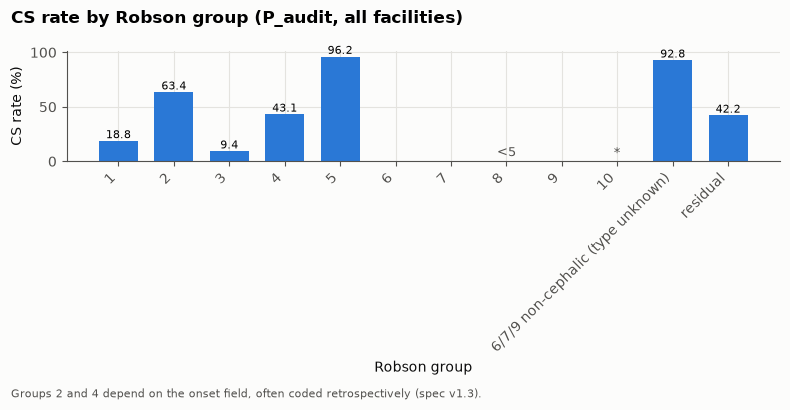

Vogel comparison not available: reference file absent (never invented).


In [6]:
rows = overall.index.tolist()
observed_rates = [
    v if v in HIDDEN else 100 * as_number(v) for v in overall["cs_rate"].tolist()
]
show(
    figures.bar_chart(
        rows,
        observed_rates,
        "CS rate by Robson group (P_audit, all facilities)",
        "Robson group",
        "CS rate (%)",
        note="Groups 2 and 4 depend on the onset field, often coded retrospectively.",
    )
)
if "ref_cs_rate" in overall.columns:
    groups_only = overall.loc[[r for r in rows if r.isdigit()]]
    comparison = pd.DataFrame(
        {
            "observed CS rate (%)": groups_only["cs_rate"].map(
                lambda v: v if v in HIDDEN else 100 * as_number(v)
            ),
            "reference CS rate (%)": 100 * groups_only["ref_cs_rate"].map(as_number),
            "observed share (%)": groups_only["pct_of_deliveries"].map(
                lambda v: v if v in HIDDEN else 100 * as_number(v)
            ),
            "reference share (%)": 100 * groups_only["ref_pct_of_deliveries"].map(as_number),
        }
    )
    display(Markdown("**Observed vs Vogel reference (all facilities)**"))
    display(comparison.round(1))
else:
    print("Vogel comparison not available: reference file absent (never invented).")

## 2. Facility contributions

The same table per facility. The relative contribution shows which groups drive each facility's CS
rate; comparing group sizes across facilities shows how different their case mix is before any
modelling. Grey cells are hidden (`<5` or `*`).

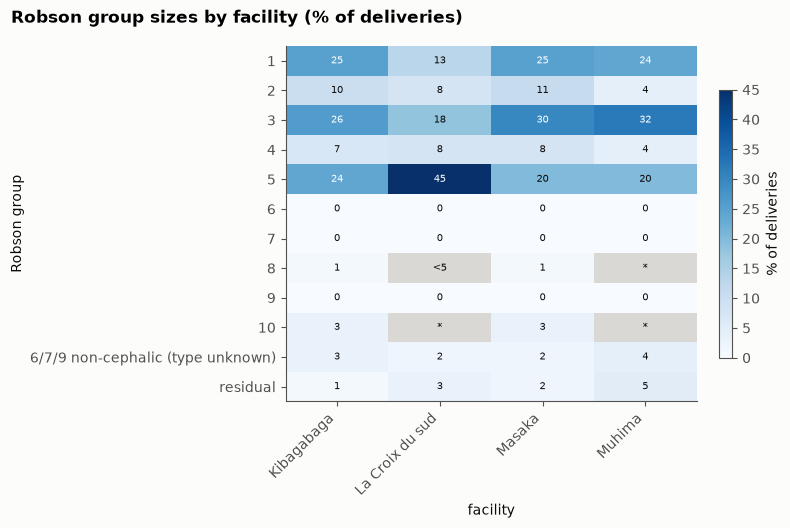

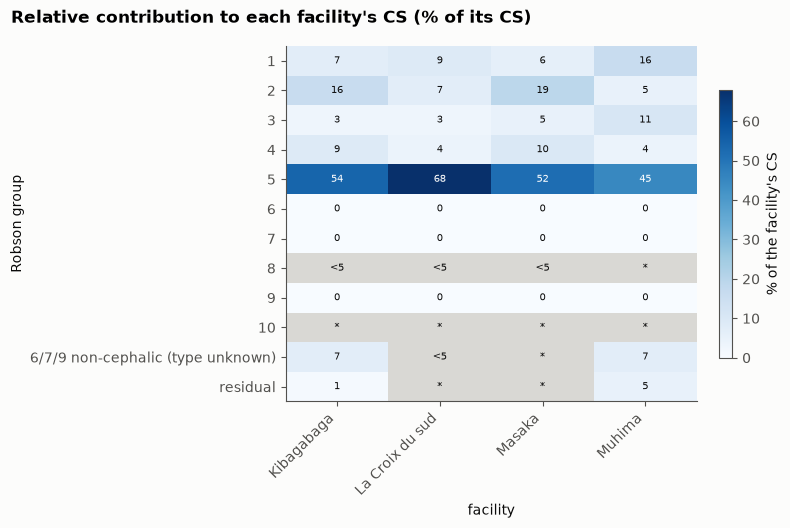

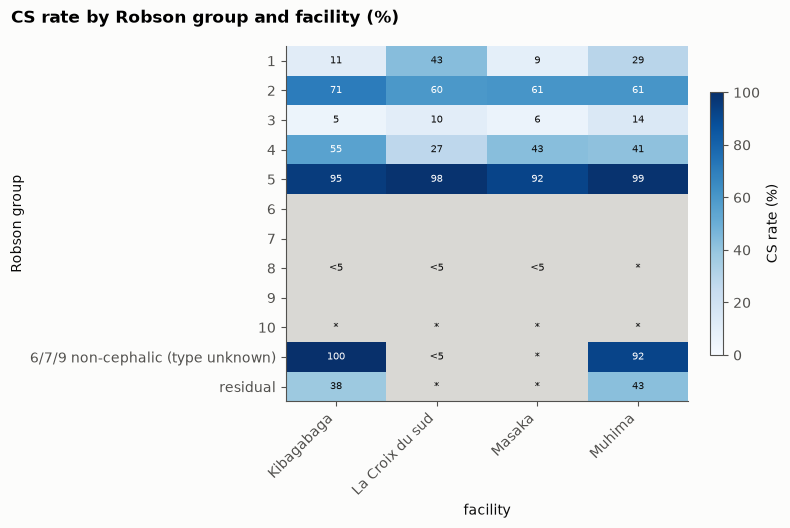

In [7]:
by_facility = audit_table[audit_table["facility"] != OVERALL]
order = overall.index.tolist()


def matrix(column: str) -> pd.DataFrame:
    pivot = by_facility.pivot(index="row", columns="facility", values=column).reindex(order)
    return pivot.map(lambda v: v if v in HIDDEN else 100 * as_number(v))


show(
    figures.heatmap(
        matrix("pct_of_deliveries"),
        "Robson group sizes by facility (% of deliveries)",
        "facility",
        "Robson group",
        "% of deliveries",
        fmt="{:.0f}",
    )
)
show(
    figures.heatmap(
        matrix("rel_contribution"),
        "Relative contribution to each facility's CS (% of its CS)",
        "facility",
        "Robson group",
        "% of the facility's CS",
        fmt="{:.0f}",
    )
)
show(
    figures.heatmap(
        matrix("cs_rate"),
        "CS rate by Robson group and facility (%)",
        "facility",
        "Robson group",
        "CS rate (%)",
        vmin=0,
        vmax=100,
        fmt="{:.0f}",
    )
)

## 3. RQ1: case-mix adjustment of facility CS rates

Three logistic models on P_audit (statsmodels `Logit`):

| Model | Specification |
|---|---|
| M_raw | cs ~ facility |
| M_adj1 | cs ~ facility + Robson level |
| M_adj2 | M_adj1 + maternal-age spline (+ C-Model covariates available in the data) |

The Robson term uses the full classification (groups 1-10, the 6/7/9 non-cephalic row and the
residual). Because onset is often coded retrospectively, every model is repeated with groups 1+2 and
3+4 merged (**sensitivity**). Robson levels with no outcome variation (all CS or none) carry no
information on facility contrasts once adjusted for, and are left out of the adjusted models (named
in the report). The *% reduction in |log OR|* measures how much of each facility's raw contrast with
the reference facility the recorded case mix accounts for.

Observed / expected ratios compare each facility's observed CS rate with the rate expected from its
case mix: against the Vogel reference (sum over groups of the facility's group share x reference CS
rate, on resolved records) and against the WHO C-Model (mean per-woman probability). Both need their
reference files; otherwise they are *not applicable*. Confidence intervals come from bootstrap
resamples drawn within facility.

In [8]:
display(Markdown(f"> **{SECTOR_CONFOUND_STATEMENT}**"))
casemix_md = (CASEMIX / "casemix.md").read_text(encoding="utf-8")
settings_lines = [line for line in casemix_md.splitlines() if line.startswith("- ")]
display(Markdown("\n".join(settings_lines)))

> **Sector confound: with four facilities, one of them private, facility and sector (public vs private) cannot be separated. Every facility odds ratio and observed/expected ratio here is a joint facility-and-sector contrast; none can be attributed to sector, or to facility practice alone. Adjustment is for recorded case mix only (descriptive, not causal).**

- Robson classifications: `full` (primary: groups 1-10, the 6/7/9 non-cephalic row and the residual as levels) and `merged_1+2_3+4` (sensitivity: groups 1+2 and 3+4 merged, since onset is often coded retrospectively, spec v1.3).
- Levels with no outcome variation (left out of adjusted models): full: none; merged_1+2_3+4: none
- M_adj2 covariates beyond age: none.
- Bootstrap: 2000 resamples within facility (1196 with all models fitted); percentile 95% CIs.
- Vogel-expected rate: not applicable (reference file absent: data\reference\vogel2015_v1.yaml (schema in robson_ml.references))
- C-Model expected rate: not applicable (reference file absent: data\reference\cmodel_v1.yaml (schema in robson_ml.references))
- M_adj2 adds no C-Model covariate: the C-Model reference file is absent.

model                                      M_raw            M_adj1  \
classification facility                                              
full           La Croix du sud  2.44 (2.03-2.94)  1.78 (1.35-2.33)   
               Masaka           0.73 (0.63-0.85)  0.73 (0.59-0.91)   
               Muhima           1.04 (0.90-1.20)  1.76 (1.42-2.17)   
merged_1+2_3+4 La Croix du sud  2.44 (2.03-2.94)  1.92 (1.49-2.47)   
               Masaka           0.73 (0.63-0.85)  0.79 (0.64-0.96)   
               Muhima           1.04 (0.90-1.20)  1.27 (1.05-1.54)   

model                                     M_adj2  
classification facility                           
full           La Croix du sud  1.50 (1.13-1.99)  
               Masaka           0.74 (0.60-0.92)  
               Muhima           1.79 (1.45-2.22)  
merged_1+2_3+4 La Croix du sud  1.61 (1.25-2.09)  
               Masaka           0.79 (0.65-0.97)  
               Muhima           1.28 (1.06-1.55)

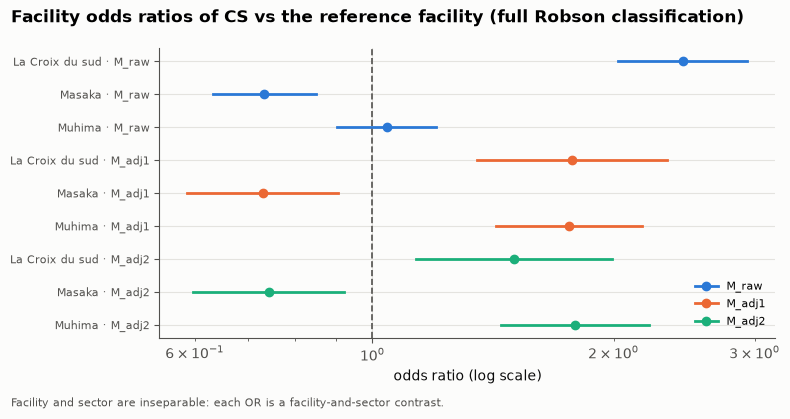

In [9]:
odds = pd.read_csv(CASEMIX / "odds_ratios.csv")
odds["OR (95% CI)"] = odds.apply(
    lambda r: f"{r['or']:.2f} ({r['ci_low']:.2f}-{r['ci_high']:.2f})", axis=1
)
display(
    odds.pivot_table(
        index=["classification", "facility"], columns="model", values="OR (95% CI)", aggfunc="first"
    ).reindex(columns=["M_raw", "M_adj1", "M_adj2"])
)
primary = odds[odds["classification"] == FULL].copy()
primary["label"] = primary["facility"] + " · " + primary["model"]
show(
    figures.forest_plot(
        primary,
        "label",
        "or",
        "ci_low",
        "ci_high",
        "Facility odds ratios of CS vs the reference facility (full Robson classification)",
        "odds ratio (log scale)",
        group="model",
        note="Facility and sector are inseparable: each OR is a facility-and-sector contrast.",
    )
)

In [10]:
reductions = pd.read_csv(CASEMIX / "reductions.csv")
reductions["% reduction (95% CI)"] = reductions.apply(
    lambda r: f"{r['pct_reduction_abs_log_or']:.0f}"
    + ("" if pd.isna(r["ci_low"]) else f" ({r['ci_low']:.0f} to {r['ci_high']:.0f})"),
    axis=1,
)
display(Markdown("**Reduction in |log OR| from M_raw** (bootstrap CI for the full classification)"))
display(
    reductions.pivot_table(
        index=["classification", "facility"],
        columns="model",
        values="% reduction (95% CI)",
        aggfunc="first",
    )
)
print(
    f"primary: '{FULL}'; sensitivity: '{MERGED}' (groups 1+2 and 3+4 merged, onset contamination)."
)

**Reduction in |log OR| from M_raw** (bootstrap CI for the full classification)

model                                           M_adj1                  M_adj2
classification facility                                                       
full           La Croix du sud           36 (12 to 62)           54 (30 to 86)
               Masaka                   -2 (-58 to 52)           4 (-52 to 62)
               Muhima           -1299 (-18428 to -237)  -1343 (-19722 to -248)
merged_1+2_3+4 La Croix du sud                      27                      46
               Masaka                               23                      25
               Muhima                             -497                    -512

primary: 'full'; sensitivity: 'merged_1+2_3+4' (groups 1+2 and 3+4 merged, onset contamination).


In [11]:
oe = pd.read_csv(CASEMIX / "observed_expected.csv", dtype=str, keep_default_na=False)
display(Markdown("**Observed / expected CS per facility**"))
display(oe.set_index("facility"))
for prefix, name in (("vogel", "Vogel-expected"), ("cmodel", "C-Model-expected")):
    values = oe[f"{prefix}_oe"].map(as_number)
    if values.notna().any():
        plot = oe.assign(
            est=values,
            low=oe[f"{prefix}_oe_low"].map(as_number),
            high=oe[f"{prefix}_oe_high"].map(as_number),
        ).dropna(subset=["est"])
        show(
            figures.forest_plot(
                plot,
                "facility",
                "est",
                "low",
                "high",
                f"Observed / {name} CS rate per facility",
                "observed / expected (log scale)",
                note="Bootstrap 95% interval (resampled within facility). O/E = 1: as expected "
                "from the recorded case mix.",
            )
        )
    else:
        print(f"{name} O/E: not applicable (see the reference status in section 0).")

**Observed / expected CS per facility**

,n,n_resolved,n_cs_resolved,observed_rate_resolved,vogel_expected_rate,vogel_oe,vogel_oe_low,vogel_oe_high,n_scored,n_cs_scored,observed_rate_scored,cmodel_expected_rate,cmodel_oe,cmodel_oe_low,cmodel_oe_high
facility,,,,,,,,,,,,,,,
ALL,5520,5213,2196,0.42125455591789757,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
Kibagabaga,1325,1269,517,0.4074074074074074,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
La Croix du sud,743,706,448,0.6345609065155807,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
Masaka,1665,1608,552,0.34328358208955223,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
Muhima,1787,1630,679,0.4165644171779141,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable


Vogel-expected O/E: not applicable (see the reference status in section 0).
C-Model-expected O/E: not applicable (see the reference status in section 0).


## 4. RQ2: missingness and under-recording

**v1.2 reframing.** The export has no blood-pressure, proteinuria or glucose fields, and pre-eclampsia and
gestational diabetes are recorded yes/no with essentially no blanks. RQ2 is therefore answered in two
parts:

* **A. Missingness** of the fields that do have it (exact gestational age, anthropometry, obstetric
  history...): by facility, by month, co-missingness patterns, and a logistic model of each field's
  missingness on facility, month, parity and CS.
* **B. Under-recording** of pre-eclampsia and GDM: a recorded "no" may be a true "yes". A
  probabilistic misclassification analysis asks how the conclusions would move if the true prevalence
  were higher than recorded.

In [12]:
display(Markdown(f"> **{MAR_STATEMENT}**"))
models = pd.read_csv(MISSING / "missingness_models.csv")
display(models.set_index("field"))

> **Missingness associated with observed variables rules out MCAR (missing completely at random). The result is consistent with MAR (missing at random given the covariates modelled), but it is not evidence for or against MNAR: whether missingness depends on the unrecorded value itself cannot be tested from the observed data.**

,n,lr_p_value,mcar_rejected,interpretation
field,,,,
gestational_age_weeks,5520,0.0,True,associated with observed variables: not MCAR; consistent with MAR given these covariat...
height_cm,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
weight_kg,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
anc_contacts,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
maternal_age,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
parity,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
previous_cs_count,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
fetal_presentation,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)
plurality,5520,NaN,NaN,not modelled (fewer than 10 missing or recorded values)


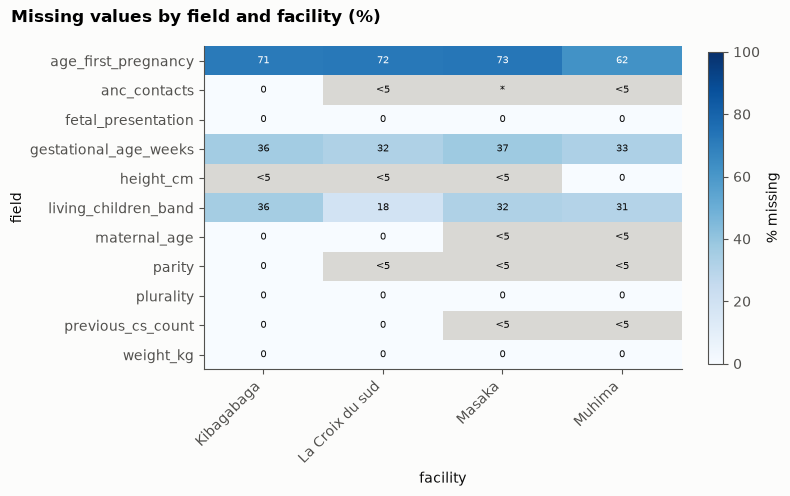

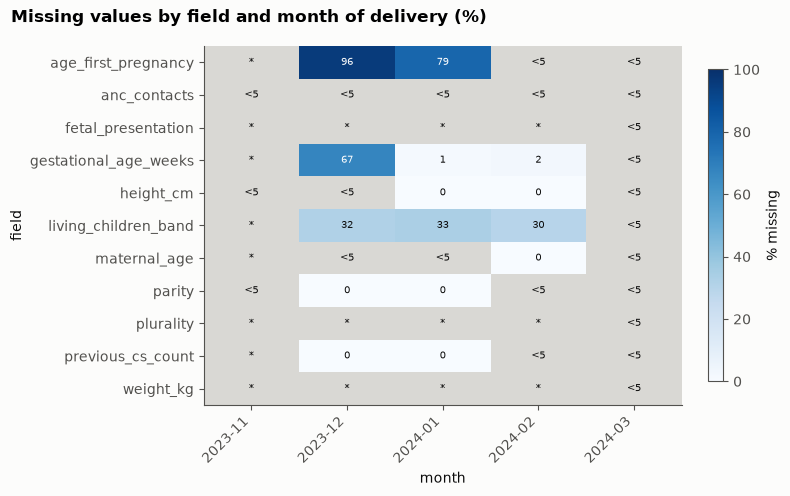

**Co-missingness patterns** (fields missing together; rare patterns pooled)

,pattern,n,pct
0,gestational_age_weeks+age_first_pregnancy,1334,24.2
1,age_first_pregnancy,1278,23.2
2,(none missing),1177,21.3
3,living_children_band+age_first_pregnancy,636,11.5
4,gestational_age_weeks+living_children_band+age_first_pregnancy,540,9.8
5,living_children_band,497,9.0
6,gestational_age_weeks,28,0.5
7,gestational_age_weeks+living_children_band,9,0.2
8,(other patterns),21,0.4


In [13]:
def missing_matrix(path: Path, by: str) -> pd.DataFrame:
    table = pd.read_csv(path, dtype=str, keep_default_na=False)
    table = table[table[by] != OVERALL]
    pivot = table.pivot(index="field", columns=by, values="pct_missing")
    return pivot.map(lambda v: v if v in HIDDEN else as_number(v))


show(
    figures.heatmap(
        missing_matrix(MISSING / "missingness_by_facility.csv", "facility_id"),
        "Missing values by field and facility (%)",
        "facility",
        "field",
        "% missing",
        vmin=0,
        vmax=100,
    )
)
show(
    figures.heatmap(
        missing_matrix(MISSING / "missingness_by_month.csv", "month"),
        "Missing values by field and month of delivery (%)",
        "month",
        "field",
        "% missing",
        vmin=0,
        vmax=100,
    )
)
display(Markdown("**Co-missingness patterns** (fields missing together; rare patterns pooled)"))
pd.read_csv(MISSING / "comissingness_patterns.csv", dtype=str, keep_default_na=False)

### B. Under-recording of pre-eclampsia and gestational diabetes

For each assumed true prevalence pi in the grid (anchored on published prevalence, from
`prevalence_v1.yaml` only), the recording sensitivity is se = recorded / pi. Within CS and vaginal
births, the expected number of true cases is *recorded yes / se*, and each recorded "no" is
reclassified "yes" with the probability that restores it, over repeated seeded draws. For each pi the
adjusted OR of CS for the condition (adjusted for facility and Robson level) and the Robson group CS
rates by reclassified status are re-estimated. The **tipping point** is the smallest pi at which a
stated conclusion differs from the conclusion on the recorded data. The conclusions are defined in
`missingness.DEFAULT_CONCLUSIONS`: *adjusted OR > 1* and *its 95% interval excludes 1*.

In [14]:
missing_md = (MISSING / "missingness.md").read_text(encoding="utf-8")
section_b = missing_md.split("## B. Under-recording", 1)[1].splitlines()
status_line = next((line for line in section_b[1:] if line.strip()), "")
display(Markdown(status_line))
conditions = sorted(
    p.name[len("under_recording_") : -len("_scenarios.csv")]
    for p in MISSING.glob("under_recording_*_scenarios.csv")
)
if conditions:
    display(Markdown(f"> {UNDER_RECORDING_ASSUMPTIONS}"))
curves = {}
for condition in conditions:
    scenarios = pd.read_csv(MISSING / f"under_recording_{condition}_scenarios.csv")
    tipping = pd.read_csv(MISSING / f"under_recording_{condition}_tipping.csv")
    display(Markdown(f"#### {condition}"))
    columns = [
        "scenario",
        "feasible",
        "reason",
        "or_median",
        "total_low",
        "total_high",
        "n_draws_fitted",
    ]
    display(scenarios[columns].set_index("scenario").round(3))
    display(tipping[["se_ratio", "conclusion", "on_recorded_data", "statement"]])
    feasible = scenarios[scenarios["feasible"].astype(bool) & scenarios["or_median"].notna()]
    feasible = feasible[feasible["scenario"] != "recorded"]
    if len(feasible):
        curves[condition] = feasible.sort_values("assumed_prevalence_pct")
if curves:
    show(
        figures.line_curves(
            curves,
            "assumed_prevalence_pct",
            "or_median",
            "Adjusted OR of CS for the condition under assumed under-recording",
            "assumed true prevalence (%)",
            "adjusted OR (median over draws)",
            note="Each point re-estimates the OR after probabilistic reclassification of recorded "
            "'no'. Assumptions stated above.",
        )
    )

Not run: reference file absent: data\reference\prevalence_v1.yaml (schema in robson_ml.references). The assumed-prevalence grid must be anchored on published prevalence transcribed into data/reference/prevalence_v1.yaml (schema in robson_ml.references); it is never invented.

## 5. WHO C-Model

The C-Model (Souza et al., 2016) gives each woman an expected CS probability from her characteristics;
a facility's expected rate is the mean over its women. Its coefficients are transcribed from the source
into `data/reference/cmodel_v1.yaml`, never estimated from local data. **If any variable the model needs
is absent from the data, the C-Model is reported as not applicable and is not approximated.**

In [15]:
cmodel_line = next(
    (line for line in casemix_md.splitlines() if line.startswith("- C-Model expected rate:")),
    "- C-Model expected rate: not reported",
)
display(Markdown(cmodel_line))
if "WHO C-Model" not in loaded:
    display(Markdown("The coefficient file is needed; its schema is printed in section 0."))

- C-Model expected rate: not applicable (reference file absent: data\reference\cmodel_v1.yaml (schema in robson_ml.references))

The coefficient file is needed; its schema is printed in section 0.

## 6. Limitations

**Data**

* **Onset contamination.** "Planned C-section" onset is often coded after the fact. Groups
  2 and 4 (and 2a/2b/4a/4b), and by complement 1 and 3, are uncertain; the case-mix models are therefore
  repeated with 1+2 and 3+4 merged.
* **Presentation recorded only as yes/no.** Non-cephalic records of unknown type stay partial between
  groups 6, 7 and 9 and are reported as their own row; the Vogel-expected rate uses resolved records only.
* **Under-recording.** Pre-eclampsia (about 1%) and gestational diabetes (about 0.1%) are far below
  published prevalence. The sensitivity analysis shows how conclusions move under stated assumptions
  (perfect specificity, recording sensitivity uniform across facilities and groups); it does not
  estimate the true prevalence.
* **Missingness.** An association between missingness and observed variables rules out MCAR only; MAR
  cannot be confirmed and MNAR cannot be assessed from these data.
* **No clinician identifier.** Only the birth-attendant cadre is recorded (and surgeon qualification only
  for CS, which is outcome-side), so the clinician-level adjustment model is not fitted.

**Design**

* **Sector confound.** With four facilities, one of them private, facility and sector cannot be
  separated. Every facility contrast is a facility-and-sector contrast.
* **Four facilities** allow only fixed facility effects; confidence intervals for facility contrasts are
  wide, and O/E ratios depend on the reference set chosen.
* **Descriptive adjustment.** The models adjust for recorded case mix only. Differences that remain are
  not evidence of over- or under-use of cesarean section at any facility.
* **References.** Vogel (2015) reflects multi-country WHO survey populations, not Rwanda; the C-Model
  needs variables that may not be recorded here.

In [16]:
print(f"notebook executed in {time.time() - started:.0f} s (mode: {MODE})")

notebook executed in 16 s (mode: real)
